In [1]:
!pip install -qq unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 25.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 47.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 109.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━

### Unsloth is an open-source, no-code web UI for training, running and exporting open models in one unified local interface.

In [2]:
from unsloth import FastLanguageModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
device

'cuda'

In [5]:
max_seq_length = 2048 #Choose any! Unsloth also supports RoPE(Rotary Positional Embedding) scaling internally
dtype = None # None for auto detection. Float16 for Tesla T4, A100, Bfloat16 for Ampere+
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit, #will load the 4bit quantized model
    device_map = "auto"
)

==((====))==  Unsloth 2026.7.6: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


* `model_name`: Specifies the name of the pre-trained model to load
* `max_seq_length`: Defines the maximum sequence lenth(in tokens) that the model can process. max_seq_length = 2048 allows the model to process sequences upto 2048 tokens long.
* `dtype`: Specifies the datatype for model weights and computations.
  - None: Automatically selects the approppriate data type based on the hardware.
  - torch.float16: Uses 16-bit floating point precision, reducing memory usage and potentially increasing spees on compatible GPUs.
  - torch.bloat16: Similar to float16 but with a wider dynamic range, beneficial for certain hardware like NVIDIA A100 GPUs.
* `load_in_4bit`: Determines whether to laod the model using 4-bit quantization. Ideal for scenarios where memory efficiency is crucial, such as deploying models on edge devices or during experimentation.

Now we'll be using `get_peft_model` from unsloth's `FastLanguageModel` class to attach adapters(peft layers) on top of the models in order to perform QLoRA

In [6]:
# Defining paramters for LoRA model
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number >0. Suggested are 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", # Wq+ Delta W...
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16, # a higher aplha value assigns more weight to LoRA activations(scaling factor tells how much the Delta W exactly contributes to the training) 
    # as delta W = alpha/r(A*B) 
    lora_dropout = 0, # Supports any, but=0 is optimized
    bias = "none", # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth 2026.7.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


- `r`: The rank of the low-rank matrices in LoRA; higher values can capture more information but increase memory usage
- `target_modules`: List of model components(e.g., "q_proj", "k_proj") where LoRA adapters are inserted for fine-tuning
- `lora_alpha`: Scaling factor for the LoRA updates, controls the impact of the adapters on the model's outputs.
- `lora_dropout`: Dropout rate applied to LoRA layers during training to prevent overfitting.
- `bias`: Specifies how biases are handled in LoRA layers; options include "none", "all", or "lora_only".
- `use_gradient_checkpointing`: Enables gradient checkpointing to reduce memory usage during training; "unsloth" used Unsloth's optimized version.
- `random_state`: Seed for random number generators to ensure reproducibility of training results.
- `use_rslora`: Boolean indicating whether to use Rank-Stabilized LoRA(rsLoRA) for potentially more stable training.
- `loftq_config`: Configuration for Low-Rank Quantization(LoftQ); set to None to disable ths feature

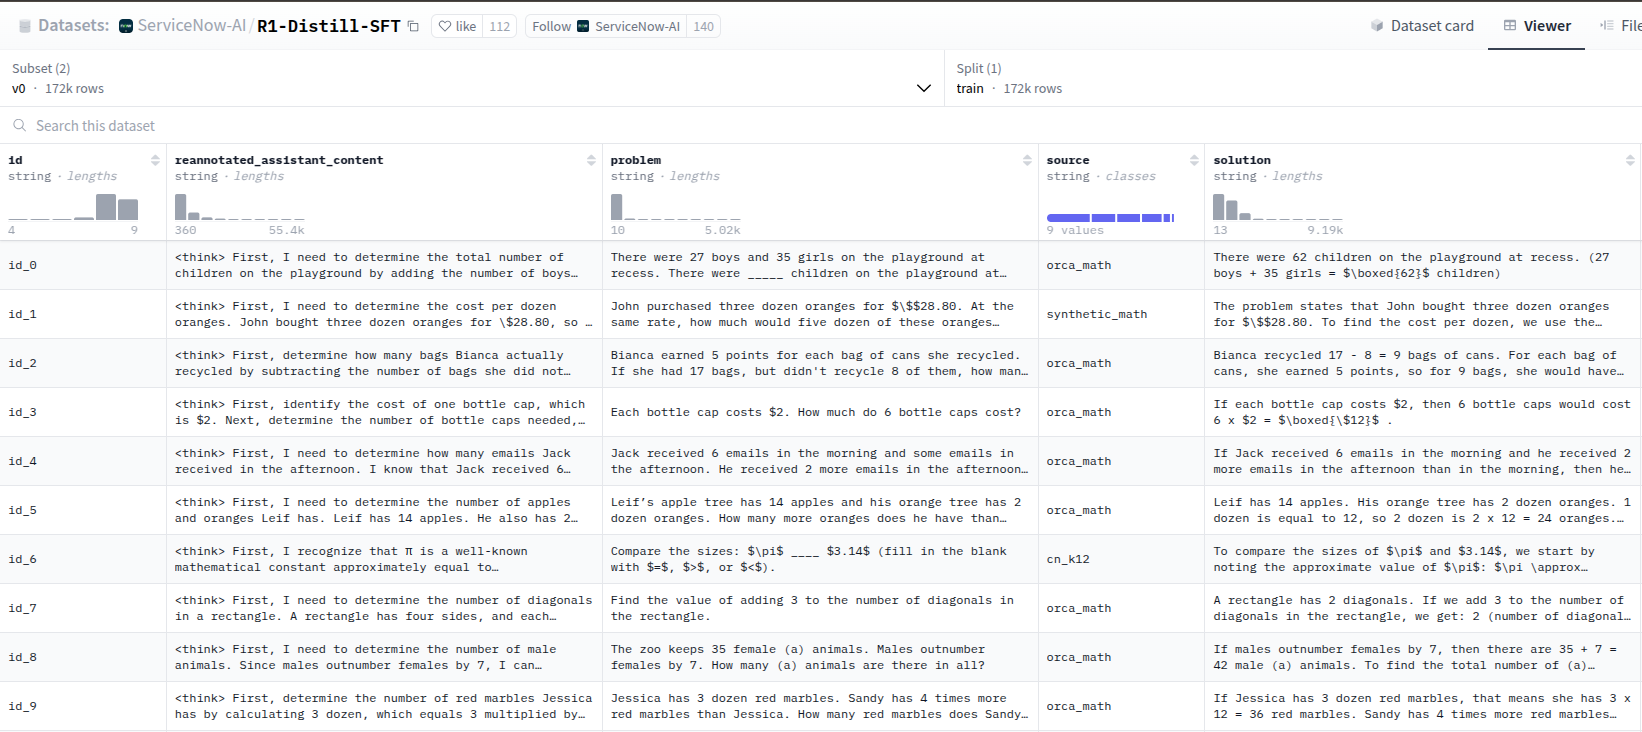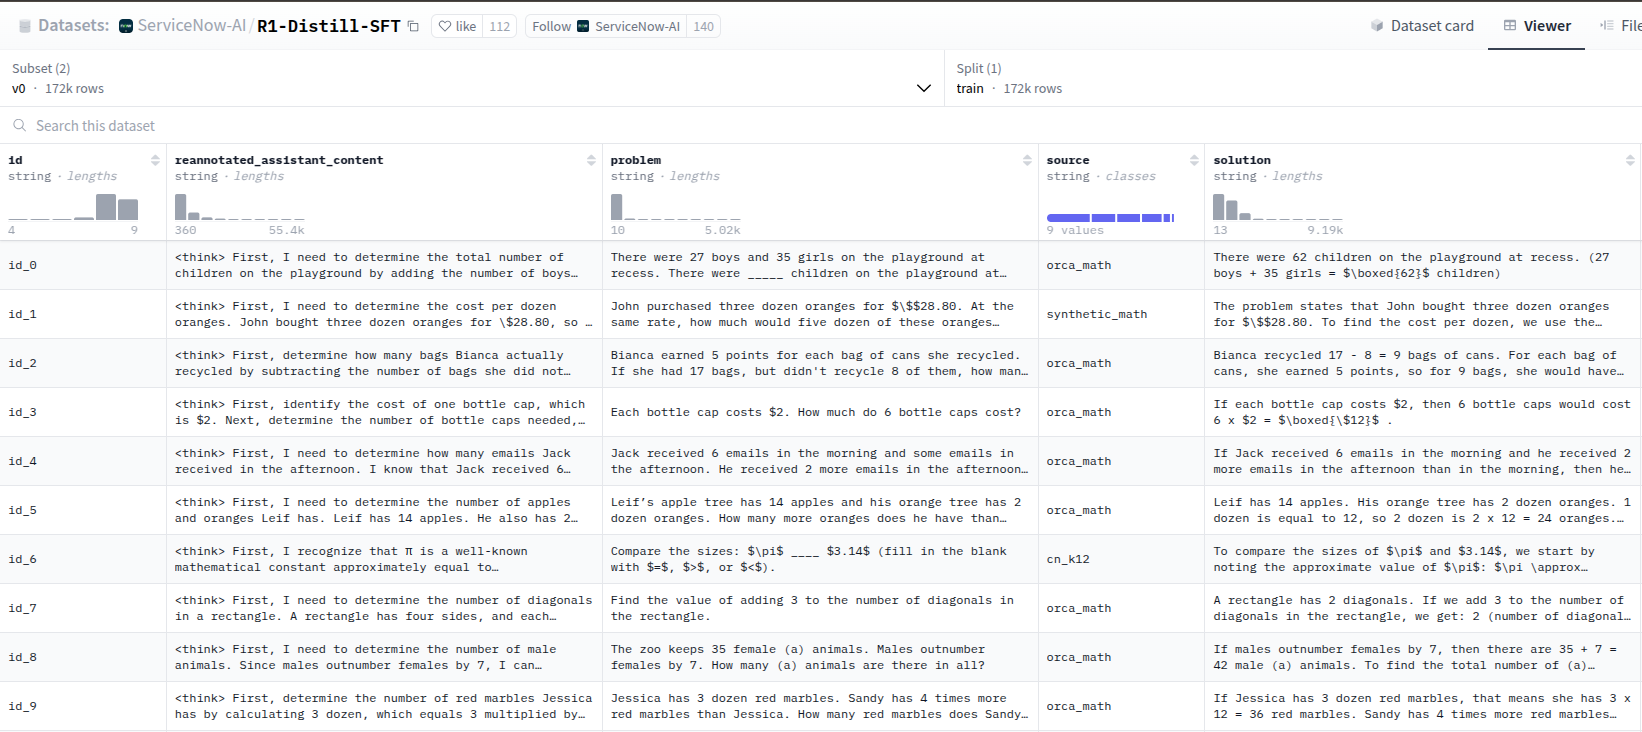

In [7]:
from datasets import load_dataset
dataset = load_dataset("ServiceNow-AI/R1-Distill-SFT",'v0', split = "train")

README.md: 0.00B [00:00, ?B/s]

v0/train-00000-of-00003.parquet:   0%|          | 0.00/180M [00:00<?, ?B/s]

v0/train-00001-of-00003.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

v0/train-00002-of-00003.parquet:   0%|          | 0.00/188M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/171647 [00:00<?, ? examples/s]

In [8]:
print(dataset[:5])

{'id': ['id_0', 'id_1', 'id_2', 'id_3', 'id_4'], 'reannotated_assistant_content': ['<think>\nFirst, I need to determine the total number of children on the playground by adding the number of boys and girls.\n\nThere are 27 boys and 35 girls.\n\nAdding these together: 27 boys + 35 girls = 62 children.\n\nTherefore, the total number of children on the playground is 62.\n</think>\n\nTo find the total number of children on the playground, we simply add the number of boys and girls together.\n\n\\[\n\\text{Total children} = \\text{Number of boys} + \\text{Number of girls}\n\\]\n\nPlugging in the given values:\n\n\\[\n\\text{Total children} = 27 \\text{ boys} + 35 \\text{ girls} = 62 \\text{ children}\n\\]\n\n**Final Answer:**\n\n\\[\n\\boxed{62}\n\\]', '<think>\nFirst, I need to determine the cost per dozen oranges. John bought three dozen oranges for \\$28.80, so I can find the cost per dozen by dividing the total cost by the number of dozens.\n\nNext, with the cost per dozen known, I can 

#### Now we'll create a prompt template that will be used to finetune our Llama model

In [9]:
r1_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
{}
</problem>

{}
{}
"""

EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(examples):
    problems = examples["problem"]
    thoughts = examples["reannotated_assistant_content"]
    solutions = examples["solution"]
    texts = []

    for problem, thought, solution in zip(problems, thoughts, solutions):
        text = r1_prompt.format(problem, thought, solution) + EOS_TOKEN
        texts.append(text)

    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched = True, num_proc = 1)

Map (num_proc=1):   0%|          | 0/171647 [00:00<?, ? examples/s]

### Trainer Setup:

* `model` and `tokenizer`: These are the model and tokenizer objects that will be trained.
* `train_dataset`: The dataset used for training
* `dataset_text_field`: Specifies the field in the dataset that contains the text data.
* `max_seq_length`: Maximum sequence length for the input data.
* `dataset_num_proc`: Number of processes to use for data loading.
* `packing`: If True, enables sequence packing(concatenates multiple examles into a single sequence to better utilize tokens).

### Training Arguments:
* `per_device_train_batch_size`: Number of samples per batch for each device.
* `gradient_accumulation_steps`: Number of steps to accumulate gradients before updating model weights.
* `warmup_steps`: Number of steps for learning rate warmup.
* `max_steps`: Total number of trianing steps
* `learning_rate`: Learning rate for the optimizer.
* `fp16` and `bf16`: Specifies whether to use 16-bit floating point precision of bfloat16, depending on hardware support.
* `logging_steps`: Frequency of logging training progress.
* `optim`: Optimizer type, here using an 8-bit version of AdamW.
* `weight_decay`: Regularization parameter for weight decay.
* `lr_scheduler_type`: Type of learning rate scheduler.
* `seed`: Random seed for reproducibility.
* `output_dir`: Directory where the training outputs will be saved.
* `report_to`: Integration for observability tools like "wanndb", "tensorboard", etc.

In [10]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

FastLanguageModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 1, # Number of processors to use for processing the dataset
    packing = False, # Can make training 5x faster for short sequences
    args = TrainingArguments(
        per_device_train_batch_size = 2, # The batch size per GPU/TPU core
        gradient_accumulation_steps = 4, # Nummber of steps to perform before each gradient accumulation
        warmup_steps = 5, # Few updates with low learning rate before actual training
        max_steps = 60, # Specifies the total number of training steps (batches) to run.
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit", # Optimizer
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Using this for WandB etc for observability
        save_strategy = "no", # Disables intermediate checkpointing if you only want final save
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/171647 [00:00<?, ? examples/s]

In [11]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 171,647 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.102059
2,1.132385
3,1.186445
4,1.097105
5,0.921370
6,0.948099
7,0.843965
8,0.815539
9,0.861222
10,0.820406


In [12]:
from unsloth.chat_templates import get_chat_template
sys_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
{}
</problem>
"""

message = sys_prompt.format("How many r's are present in 'strawberry'?")
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": message},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 1024, use_cache = True, temperature = 1.5, min_p = 0.1)
response = tokenizer.batch_decode(outputs)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_att

In [13]:
print(response[0])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
How many r's are present in'strawberry'?
</problem>
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Hmm, let me try to figure out how many r's are in the word "strawberry". Maybe I can count them manually, start from the first letter "S", then move through each letter in the word. I'll make sure not to miss any r's.

First, the letter "S" at the beginning, that's an "S". Then there's an "t". That's a "t", but I don't see an "R" here. Let's move on to the "R" in the next letter. It's the "A" with an "R" attached, so that one counts. The "W" after that, but no "R". T

In [20]:
import shutil

# Remove the mismatched folder
shutil.rmtree("chintan-001-3B", ignore_errors=True)
print("Old folder deleted successfully!")

Old folder deleted successfully!


In [21]:
model.save_pretrained("subhrajyoti-001-3B") #Local saving
tokenizer.save_pretrained("subhrajyoti-001-3B")

('subhrajyoti-001-3B/tokenizer_config.json',
 'subhrajyoti-001-3B/chat_template.jinja',
 'subhrajyoti-001-3B/tokenizer.json')

In [23]:
model.save_pretrained_gguf("subhrajyoti-001-3B-GGUF", tokenizer)

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in subhrajyoti-001-3B-GGUF/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:20<00:00, 10.11s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:43<00:00, 21.93s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/subhrajyoti-001-3B-GGUF`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF q8_0 might take 3 minutes.
\        /    [2] Single-pass export: converting straight to ['q8_0'] - no separate quantize step.
 "-____-"     In total, you will have to wait at least 6 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b10194-mix-f08678f (app-b10194-mix-f08678f-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into q8_0 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['subhrajyoti-001-3B-GGUF_gguf/llama-3.2-3b-instruct.Q8_0.gguf']
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files:

{'save_directory': 'subhrajyoti-001-3B-GGUF',
 'gguf_directory': 'subhrajyoti-001-3B-GGUF_gguf',
 'gguf_files': ['subhrajyoti-001-3B-GGUF_gguf/llama-3.2-3b-instruct.Q8_0.gguf'],
 'modelfile_location': 'subhrajyoti-001-3B-GGUF_gguf/Modelfile',
 'want_full_precision': True,
 'is_vlm': False,
 'fix_bos_token': False}

## Running the model via Ollama

In [26]:
# 1. Update package list and install zstd
!apt-get update -y && apt-get install -y zstd

# 2. Run the Ollama installation script
!curl -fsSL https://ollama.com/install.sh | sh

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [102 kB]
Get:13 https://r2u.stat.illinois.

In [27]:
import subprocess
subprocess.Popen(["ollama", "serve"])
import time
time.sleep(3)

Couldn't find '/root/.ollama/id_ed25519'. Generating new private key.
Your new public key is: 

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIFy7DgmM5c5VRQXCG5ruAe08cJHLO7caGz7sIw0St23/



time=2026-08-01T20:53:08.543Z level=INFO source=routes.go:1947 msg="server config" env="map[CUDA_VISIBLE_DEVICES: GGML_VK_VISIBLE_DEVICES: GPU_DEVICE_ORDINAL: HIP_VISIBLE_DEVICES: HSA_OVERRIDE_GFX_VERSION: HTTPS_PROXY: HTTP_PROXY: LLAMA_ARG_FIT: LLAMA_ARG_FIT_TARGET: NO_PROXY: OLLAMA_CONTEXT_LENGTH:0 OLLAMA_DEBUG:INFO OLLAMA_DEBUG_LOG_REQUESTS:false OLLAMA_EDITOR: OLLAMA_FLASH_ATTENTION:false OLLAMA_GO_TEMPLATE:true OLLAMA_GPU_OVERHEAD:0 OLLAMA_HOST:http://127.0.0.1:11434 OLLAMA_IGPU_ENABLE: OLLAMA_KEEP_ALIVE:5m0s OLLAMA_KV_CACHE_TYPE: OLLAMA_LLM_LIBRARY: OLLAMA_LOAD_TIMEOUT:5m0s OLLAMA_MAX_LOADED_MODELS:0 OLLAMA_MAX_QUEUE:512 OLLAMA_MAX_TRANSFER_STREAMS:4 OLLAMA_MODELS:/root/.ollama/models OLLAMA_NOHISTORY:false OLLAMA_NOPRUNE:false OLLAMA_NO_CLOUD:false OLLAMA_NUM_PARALLEL:1 OLLAMA_ORIGINS:[http://localhost https://localhost http://localhost:* https://localhost:* http://127.0.0.1 https://127.0.0.1 http://127.0.0.1:* https://127.0.0.1:* http://0.0.0.0 https://0.0.0.0 http://0.0.0.0:* 

In [28]:
print(tokenizer._ollama_modelfile)


FROM {__FILE_LOCATION__}
TEMPLATE """{{ if .Messages }}
{{- if or .System .Tools }}<|start_header_id|>system<|end_header_id|>
{{- if .System }}

{{ .System }}
{{- end }}
{{- if .Tools }}

You are a helpful assistant with tool calling capabilities. When you receive a tool call response, use the output to format an answer to the original use question.
{{- end }}
{{- end }}<|eot_id|>
{{- range $i, $_ := .Messages }}
{{- $last := eq (len (slice $.Messages $i)) 1 }}
{{- if eq .Role "user" }}<|start_header_id|>user<|end_header_id|>
{{- if and $.Tools $last }}

Given the following functions, please respond with a JSON for a function call with its proper arguments that best answers the given prompt.

Respond in the format {"name": function name, "parameters": dictionary of argument name and its value}. Do not use variables.

{{ $.Tools }}
{{- end }}

{{ .Content }}<|eot_id|>{{ if $last }}<|start_header_id|>assistant<|end_header_id|>

{{ end }}
{{- else if eq .Role "assistant" }}<|start_header

In [31]:
# Check what is written inside your Modelfile
with open("./subhrajyoti-001-3B-GGUF_gguf/Modelfile", "r") as f:
    print(f.read())


FROM llama-3.2-3b-instruct.Q8_0.gguf
TEMPLATE """{{ if .Messages }}
{{- if or .System .Tools }}<|start_header_id|>system<|end_header_id|>
{{- if .System }}

{{ .System }}
{{- end }}
{{- if .Tools }}

You are a helpful assistant with tool calling capabilities. When you receive a tool call response, use the output to format an answer to the original use question.
{{- end }}
{{- end }}<|eot_id|>
{{- range $i, $_ := .Messages }}
{{- $last := eq (len (slice $.Messages $i)) 1 }}
{{- if eq .Role "user" }}<|start_header_id|>user<|end_header_id|>
{{- if and $.Tools $last }}

Given the following functions, please respond with a JSON for a function call with its proper arguments that best answers the given prompt.

Respond in the format {"name": function name, "parameters": dictionary of argument name and its value}. Do not use variables.

{{ $.Tools }}
{{- end }}

{{ .Content }}<|eot_id|>{{ if $last }}<|start_header_id|>assistant<|end_header_id|>

{{ end }}
{{- else if eq .Role "assistant" }}<|

In [32]:
!ollama create unsloth_model -f /kaggle/working/subhrajyoti-001-3B-GGUF_gguf/Modelfile

]11;?\[GIN] 2026/08/01 - 21:00:33 | 200 |      42.895µs |       127.0.0.1 | HEAD     "/"
gathering model components ⠋ gathering model components ⠙ gathering model components ⠹ gathering model components ⠸ gathering model components ⠼ gathering model components ⠴ gathering model components ⠦ gathering model components ⠧ gathering model components ⠇ gathering model components ⠏ gathering model components ⠋ gathering model components ⠙ gathering model components ⠹ gathering model components ⠸ gathering model components ⠼ gathering model components ⠴ gathering model components ⠦ gathering model components ⠧ gathering model components ⠇ gathering model components ⠏ gathering model components ⠋ gathering model components ⠙ gathering model components ⠹ gathering model components ⠸ gathering model components ⠼ gathering model components ⠴ gathering model components ⠦ gathering model components ⠧ gathering model components ⠇ gathering model components ⠏ gathering model components ⠋ gathering 

time=2026-08-01T21:00:59.818Z level=INFO source=quantization.go:124 msg="quantizing model" type=COPY input=/root/.ollama/models/blobs/sha256-e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 output=/root/.ollama/models/blobs/COPY549547241
load_backend: loaded CPU backend from /usr/local/lib/ollama/libggml-cpu-skylakex.so
llama_print_build_info: build = 1 (b4d6c7d8f)
llama_print_build_info: built with GNU 13.3.1 for Linux x86_64
llama_quantize: quantizing '/root/.ollama/models/blobs/sha256-e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283' to '/root/.ollama/models/blobs/COPY549547241' as COPY
llama_model_loader: loaded meta data with 36 key-value pairs and 255 tensors from /root/.ollama/models/blobs/sha256-e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.archi

gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠼ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠴ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠦ 

llama_model_loader: - kv  29:                      tokenizer.ggml.merges arr[str,280147]  = ["Ġ Ġ", "Ġ ĠĠĠ", "ĠĠ ĠĠ", "...
llama_model_loader: - kv  30:                tokenizer.ggml.bos_token_id u32              = 128000
llama_model_loader: - kv  31:                tokenizer.ggml.eos_token_id u32              = 128009
llama_model_loader: - kv  32:            tokenizer.ggml.padding_token_id u32              = 128004
llama_model_loader: - kv  33:               tokenizer.ggml.add_bos_token bool             = true
llama_model_loader: - kv  34:               tokenizer.ggml.add_sep_token bool             = false
llama_model_loader: - kv  35:                    tokenizer.chat_template str              = {{- bos_token }}\n{%- if custom_tools ...
llama_model_loader: - type  f32:   58 tensors
llama_model_loader: - type q8_0:  197 tensors
[   1/ 255] output_norm.weight                   - [  3072,      1,      1,      1], type =    f32, size =    0.012 MiB
[   2/ 255] rope_freqs.weight          

gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠧ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠇ 

...

gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠦ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠧ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠇ 

[ 253/ 255] blk.27.ffn_gate.weight               - [  3072,   8192,      1,      1], type =   q8_0, size =   25.500 MiB
[ 254/ 255] blk.27.ffn_norm.weight               - [  3072,      1,      1,      1], type =    f32, size =    0.012 MiB
[ 255/ 255] blk.27.ffn_up.weight                 - [  3072,   8192,      1,      1], type =   q8_0, size =   25.500 MiB


gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠏ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠋ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠙ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠹ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠸ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠼ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF ⠴ gathering model components 
copying file sha256:e8250b60b67075

llama_model_quantize_impl: model size  =  3255.90 MiB (8.50 BPW)
llama_model_quantize_impl: quant size  =  3255.90 MiB (8.50 BPW)


gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF 
verifying conversion ⠋ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF 
verifying conversion ⠙ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF 
verifying conversion ⠹ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF 
verifying conversion ⠸ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF 
verifying conversion ⠼ gathering model components 
copying file sha256:e8250b60b67075b6b9d7941a852438d371faa30adc48771c9b272b0c6d211283 100% 
parsing GGUF 
verifying conversion ⠴ gathering model components 
copying file sha256:e8250b60b67075b6

In [33]:
!ollama run unsloth_model "How many 'r's are present in 'strawberry'?"

]11;?\[GIN] 2026/08/01 - 21:01:48 | 200 |      82.677µs |       127.0.0.1 | HEAD     "/"
[GIN] 2026/08/01 - 21:01:49 | 200 |  251.766406ms |       127.0.0.1 | POST     "/api/show"
⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠹ ⠸ ⠸ 

time=2026-08-01T21:01:51.429Z level=INFO source=sched.go:1019 msg="selecting single GPU for llama-server model" main_gpu=0 id=0 filter_id=0 library=CUDA name=CUDA0 description="Tesla T4" integrated=false predicted="6.7 GiB" available="13.2 GiB"
time=2026-08-01T21:01:51.429Z level=INFO source=sched.go:1138 msg="selecting GPU backend for llama-server model" library=CUDA gpu_count=1 available_gpu_count=2
time=2026-08-01T21:01:51.429Z level=INFO source=sched.go:1221 msg="disabling mmap for llama-server load due to host memory pressure" model=/root/.ollama/models/blobs/sha256-ff9860bcdcb8a034c900a822f055257435162c82dc6f826f4b110c600d107472 model_size="3.2 GiB" loaded_mmap_size="0 B" headroom="7.5 GiB" system_free="6.9 GiB" system_total="30.0 GiB" predicted_vram="6.7 GiB" available_vram="13.2 GiB"
time=2026-08-01T21:01:51.429Z level=INFO source=server.go:109 msg="using llama-server for model" model=/root/.ollama/models/blobs/sha256-ff9860bcdcb8a034c900a822f055257435162c82dc6f826f4b110c600d10

⠴ ⠦ ⠧ 

cmn  common_param:   - CUDA0   : Tesla T4 (14911 MiB, 13466 MiB free)
cmn  common_param: system_info: n_threads = 2 (n_threads_batch = 2) / 4 | CPU : SSE3 = 1 | SSSE3 = 1 | AVX = 1 | AVX2 = 1 | F16C = 1 | FMA = 1 | BMI2 = 1 | AVX512 = 1 | LLAMAFILE = 1 | REPACK = 1 | CUDA : ARCHS = 750,800,860,870,890,900,1000,1030,1100,1200,1210 | USE_GRAPHS = 1 | 
srv          init: using 5 threads for HTTP server
srv          init: The UI is disabled
srv          init: Use --ui/--no-ui (or deprecated --webui/--no-webui) to enable/disable
srv  llama_server: -----------------
srv  llama_server: CORS is set to allow all origins ('*') and no API key is set
srv  llama_server: this can be a security risk (cross-origin attacks)
srv  llama_server: more info: https://github.com/ggml-org/llama.cpp/pull/25655
srv  llama_server: -----------------
srv         start: binding port with default address family
srv    load_model: loading model '/root/.ollama/models/blobs/sha256-ff9860bcdcb8a034c900a822f055257435162c8

⠇ ⠏ ⠋ ⠙ ⠹ 

...

srv    load_model: initializing, n_slots = 1, n_ctx_slot = 32768, kv_unified = 'false'
spec common_specu: no implementations specified for speculative decoding
slot   load_model: id  0 | task -1 | new slot, n_ctx = 32768
srv    load_model: prompt cache is enabled, size limit: 8192 MiB
srv    load_model: use `--cache-ram 0` to disable the prompt cache
srv    load_model: for more info see https://github.com/ggml-org/llama.cpp/pull/16391
srv    load_model: context checkpoints enabled, max = 32, min spacing = 8192
srv          init: idle slots will be saved to prompt cache upon starting a new task
srv          init: init: chat template, example_format: '<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Hello<|im_end|>
<|im_start|>assistant
Hi there<|im_end|>
<|im_start|>user
How are you?<|im_end|>
<|im_start|>assistant
'
srv          init: init: chat template, thinking = 0
srv  llama_server: model loaded
srv  llama_server: listening on http://127.0.0.1:34387
srv  up

⠦ ⠧ 

time=2026-08-01T21:02:28.785Z level=INFO source=images.go:373 msg="template selection" model=registry.ollama.ai/library/unsloth_model:latest selected=go_template renderer="" parser="" go_template="[completion tools]" chat_template="[tools completion]" harmony=null renderer_parser=null
time=2026-08-01T21:02:28.785Z level=INFO source=sched.go:734 msg="loaded runners" count=1
time=2026-08-01T21:02:28.785Z level=INFO source=llama_server.go:1257 msg="waiting for llama-server to start responding"
time=2026-08-01T21:02:28.786Z level=INFO source=llama_server.go:1324 msg="llama-server started in 37.36 seconds"
srv  server_strea: conv_id= (empty=1)
slot get_availabl: id  0 | task -1 | selected slot by LRU, t_last = -1
srv  get_availabl: updating prompt cache
srv          load:  - looking for better prompt, base f_keep = -1.000, sim = 0.000
srv        update:  - cache state: 0 prompts, 0.000 MiB (limits: 8192.000 MiB, 32768 tokens, 8589934592 est)
srv  get_availabl: prompt cache update took 0.01 

⠏ ⠏ ⠙ ⠹ ⠹ ⠼ ⠼ ⠦ ⠦ ⠧ ⠇ ⠏ ⠋ ⠹ ⠹ ⠼ ⠴ ⠦ ⠦ ⠇ ⠇ ⠋ ⠋ ⠹ ⠹ ⠸ ⠼ ⠦ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠙ ⠹ ⠸ ⠴ ⠦ ⠧ ⠇ ⠇ ⠏ ⠙ ⠙ ⠸ ⠼ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠹ ⠸ ⠴ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠸ ⠸ ⠼ ⠦ ⠦ ⠇ ⠏ ⠏ ⠋ ⠙ ⠸ ⠸ ⠼ ⠴ ⠦ ⠇ ⠏ ⠋ ⠙ ⠹ ⠸ ⠼ ⠼ ⠦ ⠧ ⠧ ⠇ ⠏ ⠋ ⠙ ⠸ ⠼ ⠴ ⠴ ⠦ ⠧ ⠇ ⠋ ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠧ ⠏ ⠋ ⠙ ⠹ ⠸ ⠼ ⠼ ⠦ ⠦ ⠧ ⠏ ⠏ ⠋ ⠙ ⠸ ⠸ ⠼ ⠦ ⠧ ⠧ ⠏ ⠏ ⠙ ⠹ ⠹ ⠸ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠋ ⠹ ⠸ ⠼ ⠴ ⠴ ⠦ ⠧ ⠇ ⠏ ⠙ ⠙ ⠹ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠋ ⠙ ⠹ ⠼ ⠴ ⠦ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠦ ⠧ ⠏ ⠋ ⠙ ⠹ ⠸ ⠼ ⠴ ⠴ ⠦ ⠧ ⠇ ⠏ The word "strawberry" has 2 'r's.[GIN] 2026/08/01 - 21:02:50 | 200 |          1m1s |       127.0.0.1 | POST     "/api/generate"




slot print_timing: id  0 | task 0 | prompt eval time =   21346.26 ms /    24 tokens (  889.43 ms per token,     1.12 tokens per second)
slot print_timing: id  0 | task 0 |        eval time =     297.57 ms /    15 tokens (   19.84 ms per token,    50.41 tokens per second)
slot print_timing: id  0 | task 0 |       total time =   21643.83 ms /    39 tokens
slot print_timing: id  0 | task 0 |    graphs reused =         14
slot      release: id  0 | task 0 | stop processing: n_tokens = 38, truncated = 0
srv  update_slots: all slots are idle
